In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.basemap import shiftgrid
import cartopy.crs as ccrs

In [20]:
df_rst_on = pd.read_csv("rst_on.csv")
df_rst_off = pd.read_csv("rst_off.csv")
df_rlut_on = pd.read_csv("rlut_on.csv")
df_rlut_off = pd.read_csv("rlut_off.csv")
df_rss_on = pd.read_csv("rss_on.csv")
df_rss_off = pd.read_csv("rss_off.csv")
df_rls_on = pd.read_csv("rls_on.csv")
df_rls_off = pd.read_csv("rls_off.csv")
df_hfls_on = pd.read_csv("hfls_on.csv")
df_hfls_off = pd.read_csv("hfls_off.csv")
df_hfss_on = pd.read_csv("hfss_on.csv")
df_hfss_off = pd.read_csv("hfss_off.csv")

#cloud and sea ice cover
df_sic_on = pd.read_csv("sic_on.csv")
df_sic_off = pd.read_csv("sic_off.csv")
df_sit_on = pd.read_csv("sit_on.csv")
df_sit_off = pd.read_csv("sit_off.csv")
df_clt_on = pd.read_csv("clt_on.csv")
df_clt_off = pd.read_csv("clt_off.csv")

In [3]:
df_hfls_on.head()

,lat,lon,hfls
0,-85.760587,0.000,-1.217957
1,-85.760587,5.625,-1.220036
2,-85.760587,11.250,-1.246379
3,-85.760587,16.875,-1.304802
4,-85.760587,22.500,-1.379020


In [4]:
df_hfls_off.head()

,lat,lon,hfls
0,-85.760587,0.000,-1.322735
1,-85.760587,5.625,-1.312621
2,-85.760587,11.250,-1.325960
3,-85.760587,16.875,-1.347975
4,-85.760587,22.500,-1.380540


In [5]:
print(df_hfls_on['hfls'].abs()-df_hfls_off['hfls'].abs().head(20))

0      -0.104778
1      -0.092585
2      -0.079581
3      -0.043172
4      -0.001520
          ...   
2043         NaN
2044         NaN
2045         NaN
2046         NaN
2047         NaN
Name: hfls, Length: 2048, dtype: float64


In [21]:
def find_differences(df_on,df_off,var):
    #subtract rst off from on
    merged = df_on.merge(df_off, on=['lat', 'lon'], suffixes=('_1', '_2'))
    
    # 2. Compute differences for rst
    var_diff=f"{var}_diff"
    var_one=f"{var}_1"
    var_two=f"{var}_2"
    merged[var_diff] = (merged[var_one] - merged[var_two]).abs()

    # result: columns lat, lon, rst_diff
    df = merged.copy()
    
    # make sure longitudes are in [-180, 180] for Mollweide
    df['lon'] = ((df['lon'] + 180) % 360) - 180
    
    # get sorted unique coords
    lats = np.sort(df['lat'].unique())
    lons = np.sort(df['lon'].unique())
    
    # reshape rst_diff to 2D grid [lat, lon]
    # assumes a complete rectangular grid
    grid = df.pivot(index='lat', columns='lon', values=var_diff).sort_index(axis=0).sort_index(axis=1)
    lon2d, lat2d = np.meshgrid(grid.columns.values, grid.index.values)
    
    # plot
    fig = plt.figure(figsize=(8, 4))
    ax = plt.axes(projection=ccrs.Mollweide())
    ax.set_global()
    ax.coastlines()
    
    pcm = ax.pcolormesh(
        lon2d, lat2d, grid.values,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm'
    )
    
    plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.05, label='W/m²')
    plt.title(f"Change in {var} From AMOC On to Off")
    plt.tight_layout()
    plt.savefig(f"difference_{var}.png")
    #plt.show()


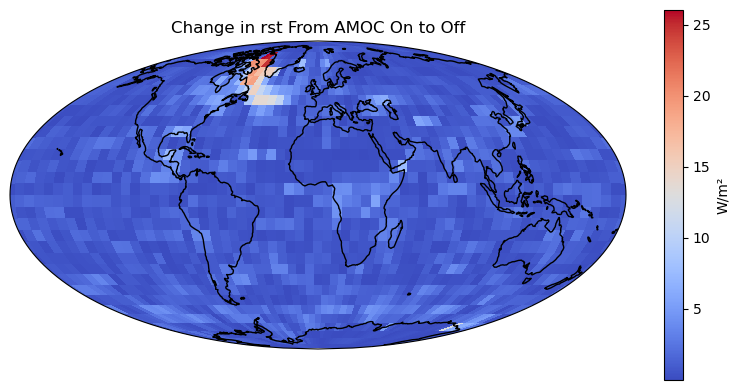

In [7]:
find_differences(df_rst_on,df_rst_off,'rst')

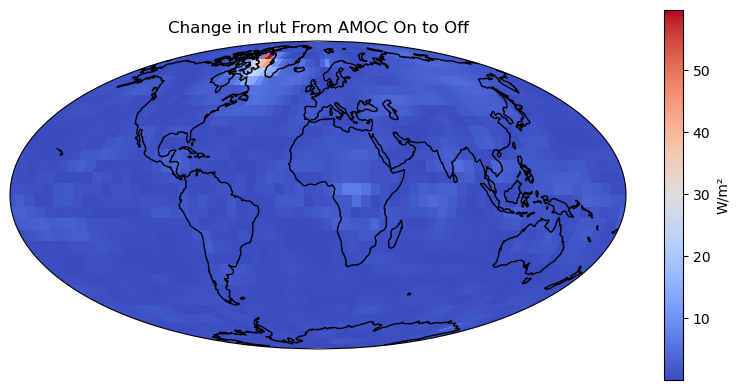

In [8]:
find_differences(df_rlut_on,df_rlut_off,'rlut')

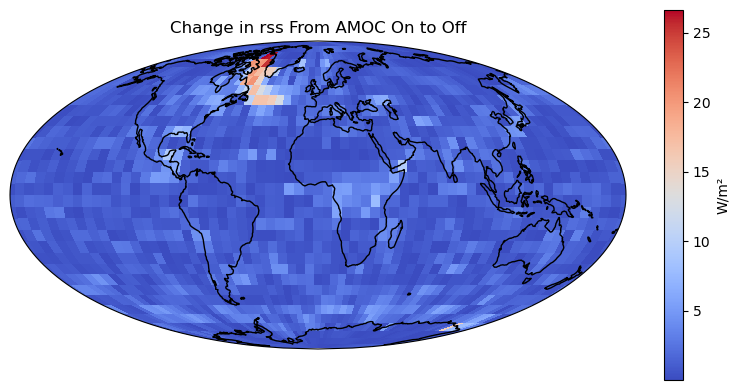

In [9]:
find_differences(df_rss_on,df_rss_off,'rss')

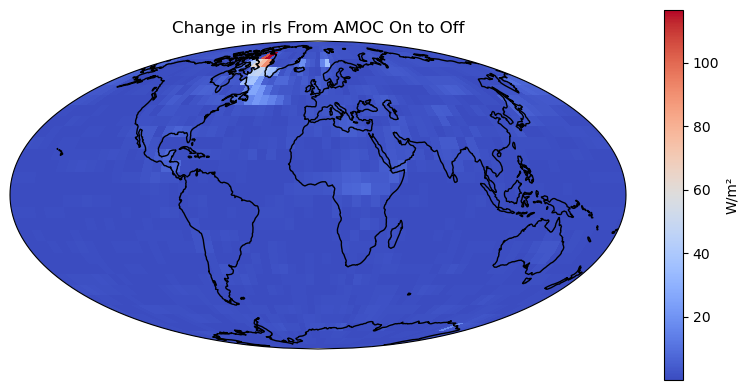

In [10]:
find_differences(df_rls_on,df_rls_off,'rls')

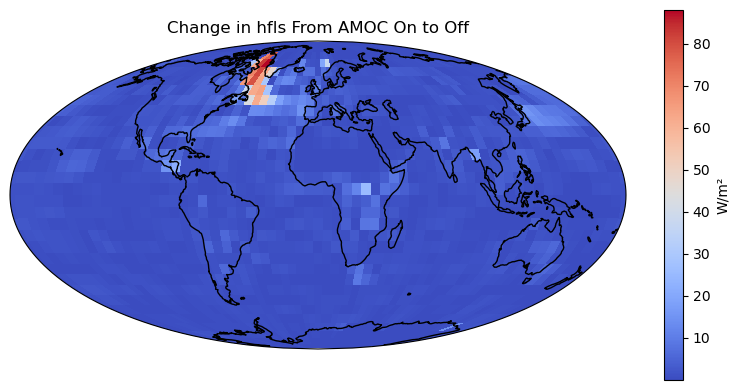

In [11]:
find_differences(df_hfls_on,df_hfls_off,'hfls')

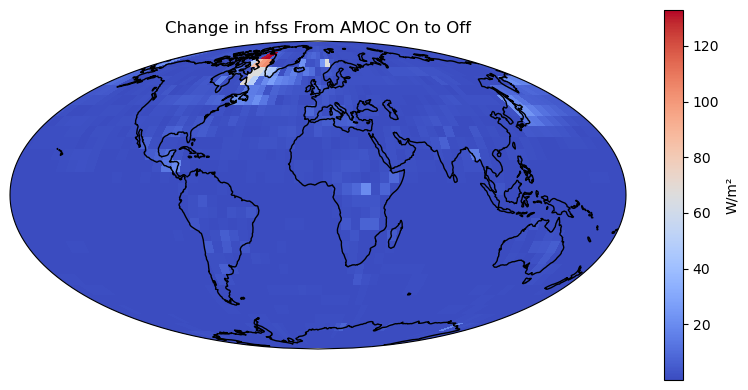

In [12]:
find_differences(df_hfss_on,df_hfss_off,'hfss')

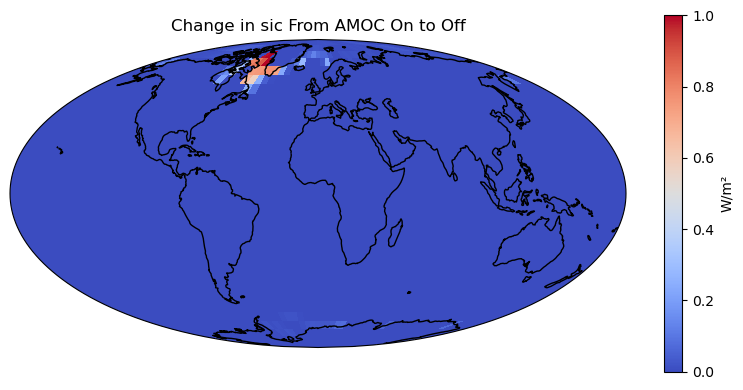

In [22]:
find_differences(df_sic_on,df_sic_off,'sic')

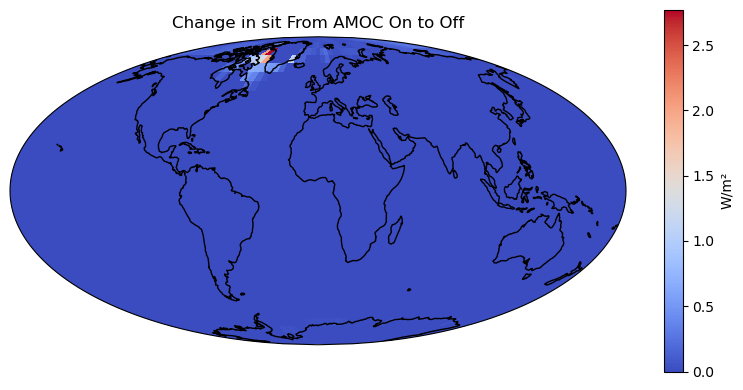

In [23]:
find_differences(df_sit_on,df_sit_off,'sit')

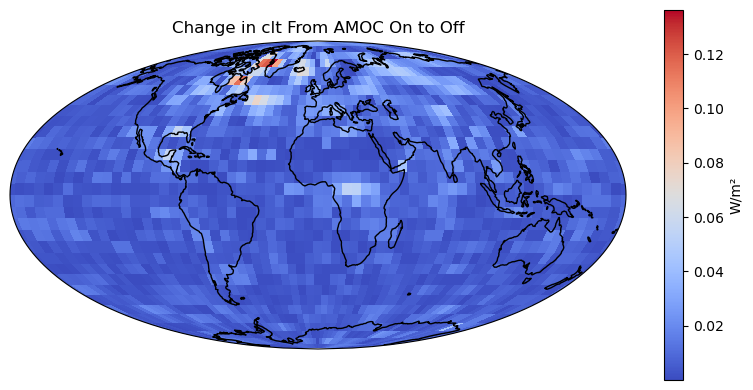

In [24]:
find_differences(df_clt_on,df_clt_off,'clt')

In [13]:
def draw_maps(df,title,values,label,figname):
    #shift 'seam' of map to pacific ocean
    df['lon'] = (df['lon'] + 180) % 360 - 180
    
    map = Basemap(projection='ortho',lat_0=30,lon_0=-50,resolution='l')
    # draw coastlines, country boundaries, fill continents.
    map.drawcoastlines(linewidth=0.25)
    map.drawcountries(linewidth=0.25)
    map.fillcontinents(color='#4863A0',lake_color='#D3D3D3')
    # draw the edge of the map projection region (the projection limb)
    map.drawmapboundary(fill_color='grey')
    # draw lat/lon grid lines every 30 degrees.
    map.drawmeridians(np.arange(0,360,30))
    map.drawparallels(np.arange(-90,90,30))
    
    # make mapgrid using lat and lon values
    lats = np.sort(df['lat'].unique())
    lons = np.sort(df['lon'].unique())
    grid = df.pivot(index='lat', columns='lon', values=values).values
    
    # Create meshgrid for Basemap
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    x, y = map(lon_grid, lat_grid)
    
    cs = map.contourf(x, y, grid, levels=20, cmap='coolwarm')
    cbar = plt.colorbar(cs, orientation='vertical')
    
    # Replace the top tick with "Land"
    ticks = cbar.get_ticks()
    tick_labels = [f"{t:.1f}" for t in ticks]
    
    # If 220 is in ticks, replace it with "Land"
    if 220 in ticks:
        tick_labels[ticks.tolist().index(220)] = "Land"
    
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(tick_labels)
    cbar.set_label(label)
    
    plt.title(title)
    plt.savefig(figname)
    plt.show()

In [14]:
df_combined_on = pd.merge(df_rst_on, df_rlut_on, on=["lat","lon"])
df_combined_off = pd.merge(df_rst_off, df_rlut_off, on=["lat","lon"])

# Create a new column which is the sum of rst and rss
df_combined_on["total_toa"] = df_combined_on["rst"] + df_combined_on["rlut"]
df_combined_off["total_toa"] = df_combined_off["rst"] + df_combined_off["rlut"]

#surf on
merged_on = pd.merge(df_rss_on, df_rls_on, on=["lat","lon"])
merged_on = pd.merge(merged_on, df_hfls_on, on=["lat","lon"])
merged_on = pd.merge(merged_on, df_hfss_on, on=["lat","lon"])
merged_on['total_surf'] = merged_on['rss'] + merged_on['rls'] + merged_on['hfls'] + merged_on['hfss']

#surf off
merged_off = pd.merge(df_rss_off, df_rls_off, on=["lat","lon"])
merged_off = pd.merge(merged_off, df_hfls_off, on=["lat","lon"])
merged_off = pd.merge(merged_off, df_hfss_off, on=["lat","lon"])
merged_off['total_surf'] = merged_off['rss'] + merged_off['rls'] + merged_off['hfls'] + merged_off['hfss']


In [15]:
merged_on.head()

,lat,lon,rss,rls,hfls,hfss,total_surf
0,-85.760587,0.000,52.935566,-55.797626,-1.217957,8.419354,4.339337
1,-85.760587,5.625,52.747020,-55.191425,-1.220036,8.086861,4.422420
2,-85.760587,11.250,52.544106,-54.428570,-1.246379,7.647752,4.516909
3,-85.760587,16.875,52.347755,-53.547220,-1.304802,7.131850,4.627583
4,-85.760587,22.500,52.139990,-52.565826,-1.379020,6.561915,4.757059


In [16]:
merged_off.head()

,lat,lon,rss,rls,hfls,hfss,total_surf
0,-85.760587,0.000,53.094883,-55.951120,-1.322735,8.535902,4.356930
1,-85.760587,5.625,52.796474,-55.237200,-1.312621,8.190451,4.437104
2,-85.760587,11.250,52.506413,-54.394480,-1.325960,7.746330,4.532303
3,-85.760587,16.875,52.280262,-53.530373,-1.347975,7.242190,4.644105
4,-85.760587,22.500,52.045185,-52.592804,-1.380540,6.710443,4.782283


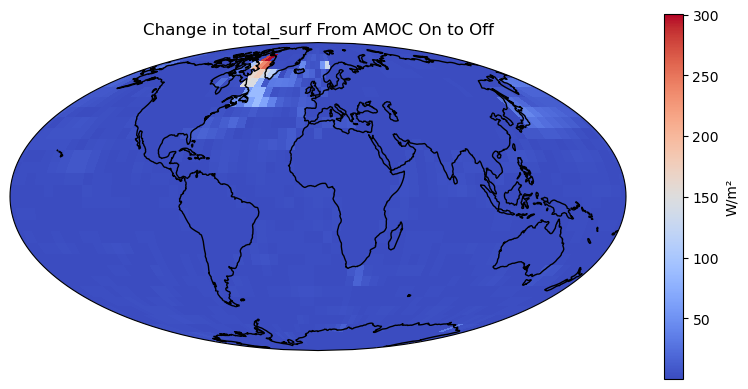

In [17]:
find_differences(merged_on,merged_off,'total_surf')

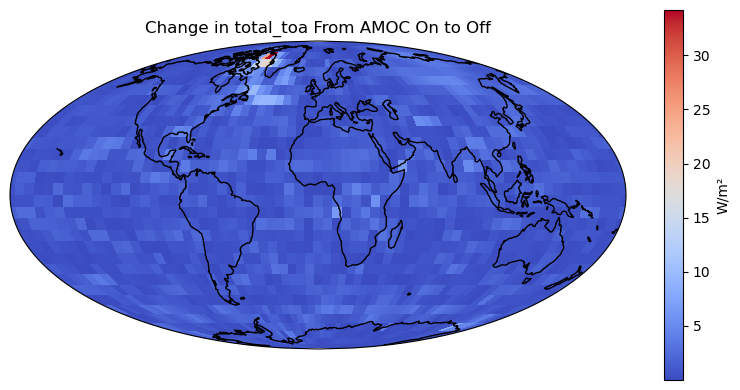

In [18]:
find_differences(df_combined_on,df_combined_off,'total_toa')

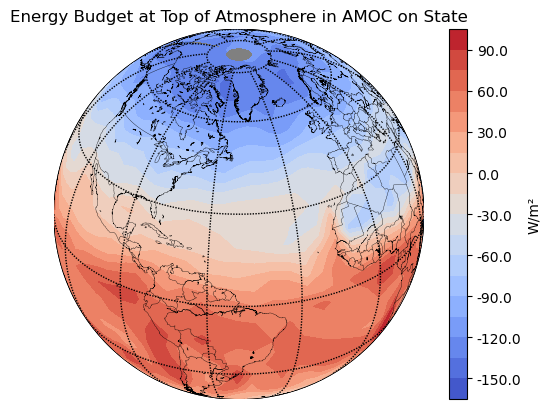

In [46]:
draw_maps(df_combined_on,"Energy Budget at Top of Atmosphere in AMOC on State","total","W/m²",
          "energy_budget_toa_on.png")

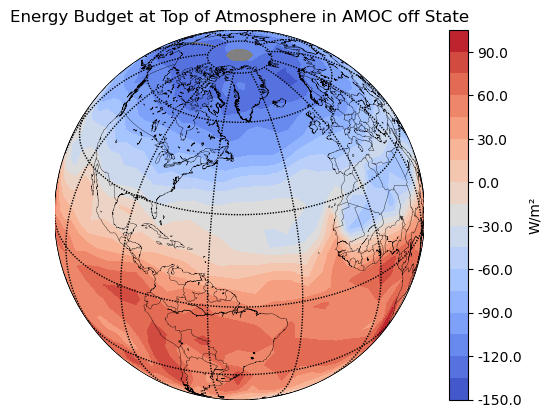

In [47]:
draw_maps(df_combined_off,"Energy Budget at Top of Atmosphere in AMOC off State","total","W/m²",
          "energy_budget_toa_off.png")

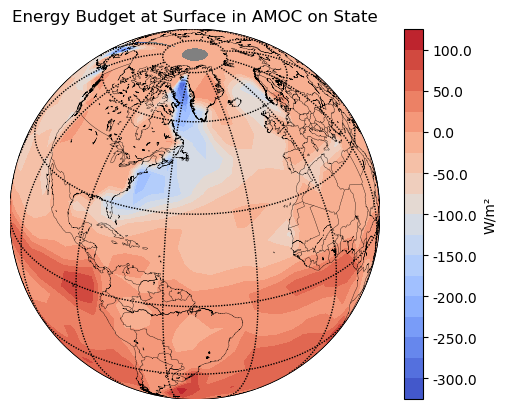

In [48]:
draw_maps(merged_on,'Energy Budget at Surface in AMOC on State','total',"W/m²","energy_budget_surf_on.png")

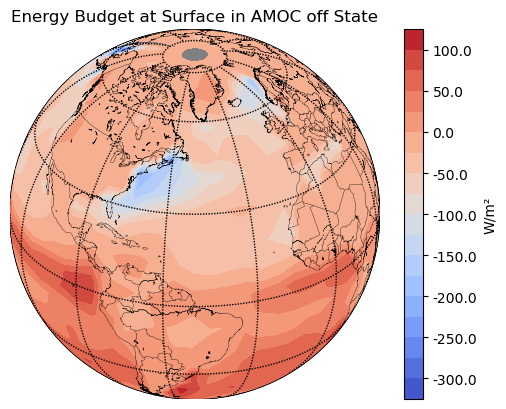

In [49]:
draw_maps(merged_off,'Energy Budget at Surface in AMOC off State','total',"W/m²","energy_budget_surf_off.png")